In [1]:
# Bibliotecas
import torch
import torch.nn as nn
from torch.optim import SGD
import matplotlib.pyplot as plt
%matplotlib inline

## DATASET

In [2]:
#this is our dataset, we need to predict y given x
x = [[1,2],[3,4],[5,6],[7,8]]
y = [[3],[7],[11],[15]]

In [3]:
# Coverting list to tensor to be able to use with pytorch
X = torch.tensor(x).float()
Y = torch.tensor(y).float()
# .float is to convert the datatype to float

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
X = X.to(device)
Y = Y.to(device)

## Model Architecture

In [5]:
class MyNeuralnet(nn.Module):
  def __init__(self):
    # When we call the super.__init__() method we ensure we are inhertiting
    super().__init__()
    self.layer1 = nn.Linear(2,8)# A linear layer
    self.activations = nn.ReLU()#activation function
    self.Layer2 = nn.Linear(8,1)

  def forward(self,x):
    x = self.layer1(x)
    x = self.activations(x) # Corrected typo here
    x = self.Layer2(x)
    return x

## Model object creation

In [11]:
model = MyNeuralnet()

## Loss Function

In [12]:
loss_func = nn.MSELoss() # funcao de loss

## Optimizer

In [13]:
opt = SGD(model.parameters(),lr=0.001) #otimizador como gradiante descrecente

## Training Loop

In [14]:
losses = []
for _ in range(50): # 50 epochs
  opt.zero_grad()
  loss_value = loss_func(model(X),Y)
  loss_value.backward()
  opt.step()
  losses.append(loss_value.detach().numpy())

## Loss Plot

Text(0, 0.5, 'loss value')

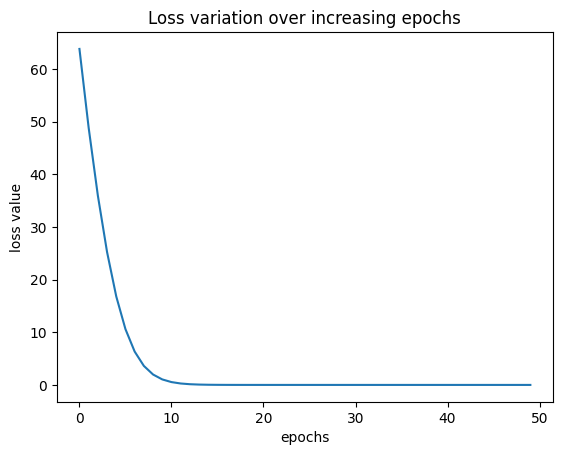

In [15]:
#Exibi imagem da variacao do loss nas 50 epochs
plt.plot(losses)
plt.title('Loss variation over increasing epochs')
plt.xlabel('epochs')
plt.ylabel('loss value')
